<!-- dads-lab-header -->
[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/mdehghani86/DADS5250-GenAI/blob/main/labs/M04/M04_Lab1_LangChain_Basics.ipynb)

![M04 Lab1 LangChain Basics](https://raw.githubusercontent.com/mdehghani86/DADS5250-GenAI/main/labs/M04/assets/images/M04_Lab1_LangChain_Basics_banner.png)

In [1]:
# === Shared lab setup: install dads5250 + load API key + sticky pill ===
# Installs the shared utilities (pp, pretty_print, lab_pill, model constants,
# setup_openai, setup_gemini) once per Colab runtime. The same OPENAI_API_KEY
# / GEMINI_API_KEY Colab secrets are used across every DADS 5250 lab, set
# them once in the 🔑 sidebar and they're picked up automatically.
import os
# Course toolkit: the shared dads5250 helpers, installed from PyPI (pypi.org/project/dads5250).
# Pinned to ==0.2.0 so this notebook runs exactly as recorded. Bump the version here to upgrade.
import importlib.util
if importlib.util.find_spec("dads5250") is None:
    !pip install -q dads5250==0.3.0

from dads5250 import (
    pp,
    pretty_print,
    lab_pill,
    setup_openai,
    setup_gemini,
    DEFAULT_CHAT_MODEL,  # newest reasoning model that supports temperature
    DEFAULT_MINI_MODEL,  # newest mini model that supports temperature
    DEFAULT_EMBED_MODEL, # current embeddings default
    DEFAULT_GEMINI_MODEL, # tracks the latest stable flash
)

lab_pill('M04 Lab 1, LangChain Basics')            # sticky banner so you always see which lab you're in


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.1/140.1 kB 14.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 131.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 103.1 MB/s eta 0:00:00


## API check

Confirm the API connection before we start. Your key is read from a Colab Secret, an environment variable, or a hidden prompt if neither is set.

**Running in Jupyter or JupyterHub instead of Colab?** There are no Colab Secrets there, so do either:
- Just run the setup cell and paste your key when it prompts (the input is hidden and not saved), or
- Set it first: in a terminal run `export OPENAI_API_KEY=sk-...`, or in a cell run `import os; os.environ["OPENAI_API_KEY"] = "sk-..."`.


In [2]:
# === API check: confirm the connection and show the model(s) this lab uses ===
client = setup_openai()        # loads OPENAI_API_KEY + verifies it works

pp({
    "OpenAI":      "connected",
    "chat model":  DEFAULT_CHAT_MODEL,
    "mini model":  DEFAULT_MINI_MODEL,
}, title="API check")

OpenAI ready  |  model: gpt-5.4-mini  |  status: connected


# Part 1, LangChain LLMs

First, the foundation: talk to **any** model through one interface. You will connect LangChain to OpenAI, send single prompts and full multi-turn conversations with `.invoke()`, compare OpenAI against Gemini on the same task, and even run open-source models (GPT-2, DistilGPT2, Falcon) locally through the same wrapper.


<div style="background: linear-gradient(135deg, #001a70 0%, #0055d4 100%); color: white; padding: 25px; text-align: center; border-radius: 10px; margin-bottom: 20px;">
  <h1 style="font-size: 32px; margin-bottom: 10px;">🧠 LangChain Lab 1: Introduction</h1>
  <p style="margin: 0; font-size: 16px;">Welcome to the first hands-on lab for LangChain! In this lab, we will:</p>
  <p style="margin-top: 10px; font-size: 18px; font-weight: bold;">Instructor: Dr. Dehghani</p>
  <p style="margin-top: 5px; font-size: 14px;">
    Learn more at <a href="https://langchain.com" target="_blank" style="color: #ffdd57; text-decoration: underline;">LangChain Website</a>
  </p>
</div>

<div style="background: #f0f5ff; border-radius: 12px; padding: 20px; border: 1px solid #0055d4;">
  <p style="line-height: 1.6; font-size: 16px; margin-bottom: 12px;">
    <strong>Why LangChain?</strong> In the previous modules you called the OpenAI API directly. That works, but every provider (OpenAI, Google, Hugging Face, Anthropic) has its own SDK, its own message format, and its own quirks. The moment you want to swap models, compare providers, add memory, or chain several steps together, you end up writing and rewriting a lot of plumbing. <strong>LangChain</strong> is the framework that removes that plumbing.
  </p>
  <p style="line-height: 1.6; font-size: 16px; margin-bottom: 12px;">
    <strong>How it works.</strong> LangChain gives every model the <em>same</em> interface. You build a small list of typed messages (<code>SystemMessage</code>, <code>HumanMessage</code>, <code>AIMessage</code>), hand it to a chat model object, and call <code>.invoke()</code>. Whether the object behind that call is GPT, Gemini, or a local Hugging Face model, your code stays identical. On top of that shared core, LangChain adds reusable building blocks, prompt templates, memory, and <em>chains</em> that pipe one step into the next, so you compose LLM apps the way you compose functions.
  </p>
  <h2 style="color: #0055d4; margin-top: 0; font-size: 24px; padding-bottom: 10px; border-bottom: 2px solid #0055d4;">Lab Objectives</h2>
  <ul style="line-height: 1.8; font-size: 16px; margin: 0; padding-left: 20px;">
    <li>Set up LangChain in Google Colab and connect it to an OpenAI model</li>
    <li>Send single prompts and full multi-turn conversations through the unified <code>.invoke()</code> interface</li>
    <li>Compare several LLMs (OpenAI vs. Gemini) on the same task, side by side</li>
    <li>Run open-source models (GPT-2, DistilGPT2, Falcon) locally through the same LangChain wrapper</li>
  </ul>
</div>


In [ ]:
# ==========================================================
# 1. Install LangChain packages with Colab-compatible versions
# ==========================================================

!pip install -q --upgrade \
    "requests==2.32.4" \
    "google-auth==2.49.0" \
    langchain \
    langchain-community \
    langchain-openai \
    langchain-google-genai \
    langchain-classic \
    openai

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.3/44.3 kB 3.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 kB 5.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.7/52.7 kB 5.1 MB/s eta 0:00:00


## 🔑 Step 2: Load Your API Keys

LangChain never asks for your key directly. Instead, each provider adapter reads its key from an **environment variable** (`OPENAI_API_KEY` for OpenAI, `GEMINI_API_KEY` for Gemini). So our job in this step is simply to pull the keys out of **Colab Secrets** (the 🔑 sidebar) and copy them into those environment variables.

Why Colab Secrets instead of pasting the key into a cell? A key pasted into code gets saved in the notebook, shared, and leaked. A Secret stays out of the file and is only injected into the running session. Run the cell below; if a key is missing you will see a clear message telling you which Secret to set.

In [2]:
# ==========================================================
# 2. Load your API keys from Colab Secrets
# ==========================================================
# ⚙️ Load API Keys from Colab Secrets
# ==================================

import os                                  # Used to set environment variables for API keys
from google.colab import userdata          # To securely access stored secrets in Colab

# Retrieve your stored secrets (API keys). userdata.get RAISES when a secret
# does not exist, so we catch that and fall back to any key already in the
# environment (e.g. exported by setup_openai() on an alternative provider).
def _secret(name):
    try:
        return userdata.get(name)
    except Exception:
        return os.environ.get(name)

OPENAI_API_KEY = _secret('OPENAI_API_KEY')   # OpenAI API key for GPT models
GEMINI_API_KEY = _secret('GEMINI_API_KEY')   # Google Gemini API key for Gemini models

# Set environment variables for the APIs and confirm success
if OPENAI_API_KEY:
    os.environ["OPENAI_API_KEY"] = OPENAI_API_KEY   # Set OpenAI key as environment variable
    print("✅ OpenAI API key loaded successfully!")
else:
    print("❌ OpenAI API key not found. Please set 'OPENAI_API_KEY' in Colab secrets.")

if GEMINI_API_KEY:
    os.environ["GEMINI_API_KEY"] = GEMINI_API_KEY   # Set Gemini key as environment variable
    print("✅ Google Gemini API key loaded successfully!")
else:
    print("❌ Google Gemini API key not found. Please set 'GEMINI_API_KEY' in Colab secrets.")


✅ OpenAI API key loaded successfully!
✅ Google Gemini API key loaded successfully!


<div style="background: linear-gradient(135deg, #001a70 0%, #0055d4 100%); color: white; padding: 25px; text-align: center; border-radius: 10px; margin-bottom: 20px;">
  <h1 style="font-size: 32px; margin-bottom: 10px;">🤖 LLM Connection Check (via LangChain)</h1>
  <p style="margin: 0; font-size: 16px;">
    This step tests if <strong>LangChain</strong> can communicate with your selected language model, such as OpenAI, Gemini, or others.<br>
    All messaging with the LLM is handled by LangChain, giving you a flexible and unified workflow.
  </p>
</div>

<div style="background: #f0f5ff; border-radius: 12px; padding: 18px; margin-bottom: 22px; border: 1px solid #0055d4;">
  <ol style="line-height: 1.7; font-size: 16px; margin: 0; padding-left: 20px;">
    <li><strong>We call the language model through LangChain</strong>, not directly. LangChain manages the connection and delivers the response. 🌐</li>
    <li>If you get a valid reply, your setup is good to go for any LLM provider! 🎯</li>
  </ol>
</div>

<div style="background: #ffffff; border-radius: 12px; padding: 18px; border: 1px solid #0055d4; margin-bottom: 22px;">
  <h2 style="color: #0055d4; font-size: 22px; margin-top: 0; margin-bottom: 10px;">🔹 How <code>.invoke()</code> Works</h2>
  <p style="font-size: 16px; margin-bottom: 12px;">
    The <code>.invoke()</code> method is the main way to send prompts (messages) to a language model in LangChain.<br>
    You wrap your input in a <code>HumanMessage</code> (or <code>SystemMessage</code>, etc.), then pass it as a list.<br>
    LangChain sends the message to the LLM and returns a response object.
  </p>
  <pre style="background: #f7faff; border-radius: 8px; padding: 12px; font-size: 15px; border: 1px solid #cce0ff;">
response = llm.invoke([HumanMessage(content="Summarize LangChain in one sentence.")])
print(response.content)  # ⬅️ This gives you the model's reply
  </pre>
  <p style="font-size: 15px; margin: 0;">
    <strong>Tip:</strong> This workflow is the same for all LLM providers supported by LangChain!
  </p>
</div>


In [3]:
# ==========================================================
# 3. First LangChain call: connect to OpenAI
# ==========================================================
# This is the "hello world" of LangChain: build a model object, wrap a prompt in
# a HumanMessage, call .invoke(), and read the reply. Notice how little provider
# specific code there is. That generality is the whole point of the framework.

# Tip: browse available OpenAI chat models at https://platform.openai.com/docs/models/

# 1) Import the chat-model class (from the dedicated OpenAI adapter package) and
#    the HumanMessage type we use to label our text as coming from the user.
from langchain_openai import ChatOpenAI
from langchain_core.messages import HumanMessage

# 2) Pick which model to talk to. DEFAULT_MINI_MODEL is the shared course default
#    (a fast, cheap chat model); swap in any model id your key can access.
OPENAI_MODEL = DEFAULT_MINI_MODEL    # <-- change to any OpenAI chat model you have access to

# 3) Create the model object. This does NOT call the API yet. It just wires up a
#    reusable client that knows which model and key to use on every later .invoke().
llm = ChatOpenAI(
    model=OPENAI_MODEL,             # which model to route requests to
    api_key=OPENAI_API_KEY,         # the key we loaded from Colab Secrets above
)

# 4) Write the prompt as plain text.
prompt = "What is LangChain in one short sentence?"

# 5) Send it. We pass a LIST of messages (here just one HumanMessage); .invoke()
#    is the single call that actually hits the model and returns a response object.
response = llm.invoke([HumanMessage(content=prompt)])

# 6) The reply text lives on response.content. pretty_print renders it in a titled box.
pretty_print(response.content, title="🔹 OpenAI Response:")


ModuleNotFoundError: No module named 'langchain_openai'

In [ ]:
# ==========================================================
# 4. Inspect the response object
# ==========================================================
# .invoke() does not return a bare string. It returns a rich AIMessage object.
# Understanding its shape matters: the text is only ONE field on it. The object
# also carries token usage, the model name, finish reason, and more. Knowing this
# is what lets you read cost/usage data in real apps, not just the answer text.

# type() tells us the exact class LangChain handed back (an AIMessage).
pp({"response type": str(type(response))}, title="What does .invoke() return?")

# Echo the full object so you can SEE every field it carries (content, usage_metadata,
# response_metadata, etc.). This raw dump is intentional; study the structure.
response


🔖 Type of response: <class 'langchain_core.messages.ai.AIMessage'>

🔎 Raw response object:



AIMessage(content='LangChain is a blockchain-based platform that uses artificial intelligence to match freelance language professionals with clients in need of translation services.', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 24, 'prompt_tokens': 16, 'total_tokens': 40, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-3.5-turbo-0125', 'system_fingerprint': None, 'id': 'chatcmpl-D5xpAC6vBQe2OaJN5rieyqjtrQ17x', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019c2eef-88e3-7293-861c-2a4431085610-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 16, 'output_tokens': 24, 'total_tokens': 40, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'r

In [ ]:
# ==========================================================
# 5. Hands-on: read fields off the response
# ==========================================================
# ✋ **Hands-On: Reading the LLM's Response**
# ============================================

# Replace '-----' in the placeholders with the correct method or key to retrieve the requested information.

# Task 1: Get the main content from the LLM response
response_text = response.-----  # Extract the main response text (e.g., "content" for ChatOpenAI)

# Task 2: Get the number of prompt tokens used
prompt_tokens = response.-----  # Extract the number of tokens used in the input prompt

# Task 3: Get the number of response tokens generated
response_tokens = response.-----  # Extract the number of tokens used in the generated response


<div style="background: linear-gradient(135deg, #001a70 0%, #0055d4 100%); color: white; padding: 22px 28px 16px 28px; border-radius: 12px; margin-bottom: 18px; text-align: center;">
  <h2 style="font-size: 26px; margin-bottom: 8px;">💬 Multi-Turn Conversation in LangChain</h2>
  <p style="font-size: 16px; margin-bottom: 0;">
    A <strong>multi-turn conversation</strong> allows an AI to retain context across multiple exchanges, making interactions more natural and intelligent.<br>
    Instead of treating each query independently, the AI builds on previous inputs, improving coherence and accuracy. <span style="font-size: 22px;">🤝</span>
  </p>
</div>

<div style="background: #f0f5ff; border-radius: 12px; padding: 18px; margin-bottom: 22px; border: 1px solid #0055d4;">
  <h3 style="color: #0055d4; font-size: 20px; margin-top: 0;">✨ Why Use Multi-Turn Conversations?</h3>
  <ul style="font-size: 16px; margin: 0; padding-left: 20px; line-height: 1.7;">
    <li><strong>Context Retention</strong> - AI remembers past interactions, leading to more relevant responses.</li>
    <li><strong>Realistic Dialogue</strong> - Mimics human conversations, making chatbots more engaging.</li>
    <li><strong>Improved Accuracy</strong> - Responses are refined based on earlier exchanges.</li>
    <li><strong>Scalable Design</strong> - Supports long-form discussions without losing context.</li>
  </ul>
  <p style="font-size: 15px; margin-top: 12px;">
    <em>This approach is ideal for applications like <b>financial advisors, chatbots, research assistants</b>, and other AI-driven services that require ongoing, dynamic conversations.</em>
  </p>
</div>


In [ ]:
# ==========================================================
# 6. Multi-turn conversation: the model keeps context
# ==========================================================
# LLMs are stateless. They remember nothing between calls. The illusion of memory
# comes from US resending the whole conversation every time. Here we hand the model
# a LIST of messages that alternate Human/AI, so it can read the thread and answer
# the final question in context. The three message TYPES each play a role:
#   SystemMessage -> sets the AI's persona / rules (steers all replies)
#   HumanMessage  -> a turn spoken by the user
#   AIMessage     -> a turn previously spoken by the assistant (the "memory")
from langchain_core.messages import SystemMessage, HumanMessage, AIMessage

# Build the running transcript. Notice the last line is a Human question with no
# answer yet. That is the one the model will actually respond to, using every
# earlier turn as context.
messages = [
   SystemMessage(content="You are a coffee historian. Provide concise, one-sentence answers."), # persona + style rule
   HumanMessage(content="What is the origin of coffee?"),                                         # earlier user turn
   AIMessage(content="Coffee was first discovered in the Kaffa region of Ethiopia in the 9th century."), # earlier AI turn
   HumanMessage(content="How did coffee spread beyond Ethiopia?"),                                 # earlier user turn
   AIMessage(content="It traveled via trade routes into Yemen and then throughout the Ottoman Empire."),  # earlier AI turn
   HumanMessage(content="When did coffee reach Europe?")                                            # the NEW question to answer
]

# Send the whole transcript at once; the model reads all of it and continues the thread.
response = llm.invoke(messages)
pretty_print(response.content, title="🤖 Model Response")   # expect a one-sentence answer about coffee reaching Europe


Coffee reached Europe in the 17th century, spreading rapidly and becoming popular in places like Italy and England.


In [ ]:
# ==========================================================
# 7. Hands-on: finish the multi-turn conversation
# ==========================================================
# ✋ **Hands-On: Completing a Multi-Turn Conversation (Travel Assistant)**
#==========================================================================

# 📌 Task Instructions:
# - Below is a conversation with a **travel assistant** AI.
# - Fill in the last `HumanMessage` with a relevant travel-related question.
# - Complete the placeholder `response = ----(----)` to correctly call the LLM.

# Define a conversation with missing parts
messages = [
    SystemMessage(content="You are a helpful travel assistant, providing recommendations for destinations and travel tips."),
    HumanMessage(content="What are some must-visit places in Japan?"),
    AIMessage(content="Some must-visit places in Japan include Tokyo, Kyoto, and Osaka. Each city offers unique cultural and historical experiences."),
    HumanMessage(content="-----")  #  Task: Fill in a relevant follow-up question
]

# 🔧 Task: Complete the function to generate a response from the LLM
response = ----(----)  # Call the LLM correctly using the messages

print(response)  # Display the AI's response


<div style="background: linear-gradient(135deg, #001a70 0%, #0055d4 100%); color: white; padding: 20px; border-radius: 10px; margin-bottom: 18px;"> <h2 style="margin: 0 0 10px 0;">🔹 What is a Multi-LLM Model?</h2> <p style="margin: 0;"> A <strong>Multi-LLM model</strong> is a setup where you can send the same question or conversation to multiple large language models (LLMs), for example, OpenAI's GPT-4 and Google's Gemini, at the same time. This allows you to compare their answers, pick the best response, or even blend their strengths for more reliable results. </p> </div> <div style="background: #f0f5ff; border-radius: 12px; padding: 16px; border: 1px solid #0055d4;"> <h3 style="color: #0055d4; margin: 0 0 8px 0;">Why Does LangChain Make This Easy?</h3> <ul style="padding-left: 20px; margin: 0; font-size: 16px;"> <li><b>Unified Interface:</b> LangChain lets you connect to many LLM providers (OpenAI, Google, Hugging Face, and more) using the same simple code.</li> <li><b>Modular Chaining:</b> You can send the same messages or workflows to any model without rewriting your logic for each one.</li> <li><b>Rapid Experimentation:</b> Instantly compare outputs, performance, or reliability from different models, helping you choose the right LLM for your app or research.</li> </ul> </div> <div style="background: #fff3f3; border-radius: 12px; padding: 12px; border: 1px solid #ff6b6b; color: #d32f2f;"> <b>In short:</b> <i>LangChain empowers you to use, compare, and combine multiple AI models in one unified workflow, making your LLM projects more flexible and future-proof.</i> </div>

### What is `temperature`?

`temperature` controls how random the model's wording is. **Low** (near `0`) makes the output focused and repeatable, the same prompt gives nearly the same answer, which is what you want for facts or math. **High** (toward `1`) makes it more varied and creative, at the cost of consistency. The cells below use a higher temperature for the imaginative *coffee in 2050* prompt and a low temperature for the math problem.

In [ ]:
# ==========================================================
# 8. Multi-LLM comparison: Gemini vs. ChatGPT
# ==========================================================
# The payoff of LangChain's unified interface: the SAME messages list can be sent
# to two totally different providers with identical code. We ask both a creative
# question, then lay their answers side by side so you can judge tone and content.

from langchain_core.messages import SystemMessage, HumanMessage, AIMessage   # message types (shared across providers)
from langchain_google_genai import ChatGoogleGenerativeAI                    # adapter -> Google's Gemini
from langchain_openai import ChatOpenAI                                      # adapter -> OpenAI (ChatGPT / GPT-4 family)
import pandas as pd                                                          # to line the answers up in a table

# One prompt, reused for both models. A high-ish temperature suits a creative task.
messages = [
    SystemMessage(content="You are a fun futurist AI barista. Predict and explain what coffee culture will look like in the year 2050."),
    HumanMessage(content="Describe the biggest change in how people enjoy coffee in 2050 in few sentnene."),
]

# Build one model object per provider. temperature=0.7 -> more varied, imaginative wording.
gemini_llm  = ChatGoogleGenerativeAI(model="gemini-2.5-flash", temperature=0.7)
chatgpt_llm = ChatOpenAI(model=DEFAULT_CHAT_MODEL, temperature=0.7)

# Identical call for each. This is the whole point of the unified interface.
gemini_response  = gemini_llm.invoke(messages)     # ask Gemini
chatgpt_response = chatgpt_llm.invoke(messages)    # ask ChatGPT

# Show each answer clearly first (model results -> pretty_print, not a bare print).
pretty_print(gemini_response.content, title="☕ Gemini, coffee in 2050")
pretty_print(chatgpt_response.content, title="☕ ChatGPT, coffee in 2050")

# Then collect both into a DataFrame so they sit side by side for easy comparison.
df = pd.DataFrame({
    "Model": ["Gemini", "ChatGPT"],
    "Response": [gemini_response.content, chatgpt_response.content],
})
display(df)   # render the comparison table


,Model,Response
0,Gemini,"By 2050, the biggest shift will be the hyper-p..."
1,ChatGPT,"In 2050, the biggest change in coffee culture ..."


,Model,Response,Response Time (s)
0,Gemini,To solve the equation $3x^3 + 5x^2 - 12x + 7 =...,9.729447
1,ChatGPT,"First, we simplify the equation by subtracting...",7.313898


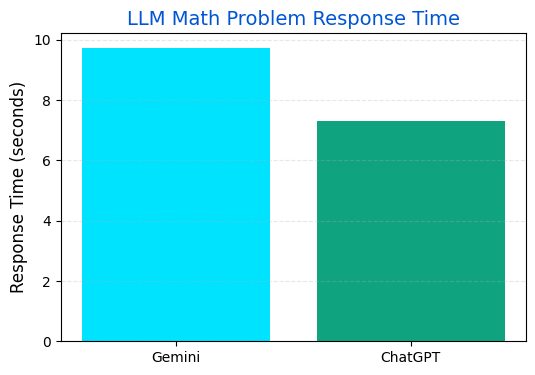

In [ ]:
# ==========================================================
# 9. Which model reasons better? (with timing)
# ==========================================================
# Now a HARD task: a cubic equation. This probes reasoning, not creativity, so we
# drop the temperature (0.3) to keep answers focused. We also TIME each call, so we
# can weigh accuracy against speed. A real tradeoff when you choose a model.

import time
import matplotlib.pyplot as plt   # for the response-time bar chart
import pandas as pd               # for the results table

from langchain_core.messages import HumanMessage
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_openai import ChatOpenAI

# The math prompt. We ask the model to flag its answers so they are easy to spot.
prompt = (
    "Solve for x in the equation: 3x^3 + 5x^2 - 12x + 7 = 21. "
    "Highlight answers by ---[ x1=  ] ---"
)

# Low temperature -> the model stays deterministic and on-task for reasoning.
gemini_llm  = ChatGoogleGenerativeAI(model="gemini-2.5-flash", temperature=0.3)
chatgpt_llm = ChatOpenAI(model=DEFAULT_CHAT_MODEL, temperature=0.3)

# Time Gemini: record the clock before and after the call, then take the difference.
start_gemini = time.time()
gemini_response = gemini_llm.invoke([HumanMessage(content=prompt)])
end_gemini = time.time()
gemini_time = end_gemini - start_gemini      # seconds Gemini took

# Time ChatGPT the same way.
start_chatgpt = time.time()
chatgpt_response = chatgpt_llm.invoke([HumanMessage(content=prompt)])
end_chatgpt = time.time()
chatgpt_time = end_chatgpt - start_chatgpt   # seconds ChatGPT took

# Show each full solution (model results -> pretty_print) so you can read the reasoning.
pretty_print(gemini_response.content, title="🧮 Gemini, cubic solution")
pretty_print(chatgpt_response.content, title="🧮 ChatGPT, cubic solution")

# Collect answers + timings into a table for a side-by-side review.
responses = pd.DataFrame({
    "Model": ["Gemini", "ChatGPT"],
    "Response": [gemini_response.content, chatgpt_response.content],
    "Response Time (s)": [gemini_time, chatgpt_time],
})
display(responses)

# Plot the two response times as bars (Gemini blue, OpenAI green) for a quick visual.
plt.figure(figsize=(6, 4))
plt.bar(
    responses["Model"],
    responses["Response Time (s)"],
    color=["#00E3FF", "#10A37F"],  # Gemini blue, OpenAI green
)
plt.ylabel("Response Time (seconds)", fontsize=12)
plt.title("LLM Math Problem Response Time", fontsize=14, color="#0055d4")
plt.grid(axis="y", linestyle="--", alpha=0.3)
plt.show()

# Reference: the equation 3x^3 + 5x^2 - 12x + 7 = 21 has three real roots:
#     x = -1,  x = 1.852 (approx),  x = -2.519 (approx)
# Check the answers above: did the model reason step by step, or just guess a number?


> **Pause and think.** Two models just solved the same cubic and were timed. Did either reach the three real roots (x = -1, x ≈ 1.852, x ≈ -2.519)? Did the faster model also get it right, or did speed cost accuracy? Which would you trust for a math-heavy task, and why?

**Your notes** *(double-click to edit)*

- More accurate model:
- Faster model:
- Which I would trust for math, and why:

In [ ]:
# ============================================================
# 🧑‍💻 Hands-On: Exploring LLM Prompt Engineering & Model Choice
# ============================================================

"""
Task:
1. Choose a different math equation (e.g., a different cubic, a system of equations, or even a word problem).
2. Experiment with your prompt style! For example:
    - Ask the LLM to "show every step"
    - Use ReAct: "First, reflect on what is needed, then solve, then verify your solution"
    - Ask for self-evaluation: "Explain why your answer makes sense"
3. Try at least TWO different LLMs (e.g., Gemini, ChatGPT, or another you have access to).
4. Record response content and timing in a DataFrame.
5. At the end, **write down your observations**:
    - Did the prompt style or LLM change the accuracy or reasoning?
    - Which model did better? Was ReAct or self-checking effective?
"""


In [ ]:
# ==========================================================
# 10. List the newest Gemini models
# ==========================================================
# Which models can your key actually reach? Rather than guessing model ids, you can
# ASK the provider for its live catalog. This cell queries Google for its model list
# and shows the 10 newest, along with what each one supports (chat, embeddings, etc.).

from google.generativeai import list_models   # Google's helper that returns available models
import pandas as pd

gemini_data = []
try:
    model_list = list(list_models())          # fetch the full catalog from the API
    # Sort by name descending. Newer versions usually sort to the top this way.
    model_list_sorted = sorted(model_list, key=lambda m: m.name, reverse=True)
    for m in model_list_sorted[:10]:          # keep only the top 10 for a readable table
        gemini_data.append({
            "Model Name": m.name,                                            # e.g. models/gemini-2.5-flash
            "Supported Methods": ", ".join(m.supported_generation_methods),  # what the model can do
        })
    df_gemini = pd.DataFrame(gemini_data)
    print("🔵 === Top 10 Newest Gemini Models ===")
    display(df_gemini)                          # tabular listing

    if not gemini_data:                         # empty list -> access/region problem
        print("⚠️ No Gemini models found. Your API key may not have access, or Gemini is not available in your region/account.")

except Exception as e:                          # network/auth failure -> show the reason
    print("❌ Error:", e)


🔵 === Top 10 Newest Gemini Models ===


/usr/local/lib/python3.12/dist-packages/google/colab/_import_hooks/_hook_injector.py:55: FutureWarning: 

All support for the `google.generativeai` package has ended. It will no longer be receiving 
updates or bug fixes. Please switch to the `google.genai` package as soon as possible.
See README for more details:

https://github.com/google-gemini/deprecated-generative-ai-python/blob/main/README.md

  loader.exec_module(module)


,Model Name,Supported Methods
0,models/veo-3.1-generate-preview,predictLongRunning
1,models/veo-3.1-fast-generate-preview,predictLongRunning
2,models/veo-3.0-generate-001,predictLongRunning
3,models/veo-3.0-fast-generate-001,predictLongRunning
4,models/veo-2.0-generate-001,predictLongRunning
5,models/text-embedding-004,embedContent
6,models/nano-banana-pro-preview,"generateContent, countTokens, batchGenerateCon..."
7,models/imagen-4.0-ultra-generate-preview-06-06,predict
8,models/imagen-4.0-ultra-generate-001,predict
9,models/imagen-4.0-generate-preview-06-06,predict


In [ ]:
# ==========================================================
# 11. List the newest OpenAI models
# ==========================================================
# The same idea for OpenAI: ask the API which models your key can see. This is how
# you confirm access to a model before you try to use it, instead of hard-coding a
# name that might 404. We show up to 15, newest first, with a little metadata.

import os
import pandas as pd
from openai import OpenAI   # OpenAI's own SDK (installed in section 1)

# Read the key from the environment (we set it earlier from Colab Secrets).
openai_key = os.environ.get("OPENAI_API_KEY", None)
model_data = []

if openai_key:                                  # only proceed if a key is present
    try:
        client = OpenAI(api_key=openai_key)     # open a client to the OpenAI API
        # Pull the catalog and sort by id descending (newest-looking ids first).
        models = sorted(client.models.list().data, key=lambda m: m.id, reverse=True)
        for m in models[:15]:                   # keep the top 15 for readability
            model_data.append({
                "Model Name": m.id,                            # the id you pass as model=
                "Owned By":  getattr(m, "owned_by", ""),       # openai / system / your org
                "Created":   getattr(m, "created", ""),        # unix timestamp of release
                "Object":    getattr(m, "object", ""),         # object type (always 'model')
            })
        df = pd.DataFrame(model_data)
        print("🔵 === Newest OpenAI Models: Metadata ===")
        display(df)                             # tabular listing
        if not model_data:
            print("⚠️ No OpenAI models found. Your API key may not have access, or your account is limited.")
    except Exception as e:                      # auth/network failure -> show the reason
        print("❌ Error checking OpenAI API key:", str(e))
else:
    print("⚠️ No OpenAI API key found in environment.")


🔵 === Newest OpenAI Models: Metadata ===


,Model Name,Owned By,Created,Object
0,whisper-1,openai-internal,1677532384,model
1,tts-1-hd-1106,system,1699053533,model
2,tts-1-hd,system,1699046015,model
3,tts-1-1106,system,1699053241,model
4,tts-1,openai-internal,1681940951,model
5,text-embedding-ada-002,openai-internal,1671217299,model
6,text-embedding-3-small,system,1705948997,model
7,text-embedding-3-large,system,1705953180,model
8,sora-2-pro,system,1759708663,model
9,sora-2,system,1759708615,model


<div style="background: linear-gradient(135deg, #001a70 0%, #0055d4 100%); color: white; padding: 24px; border-radius: 12px; margin-bottom: 20px;">
  <h2 style="margin-top:0; font-size: 26px;">🤗 Introduction: Hugging Face & Classic LLMs</h2>
  <p style="font-size: 16px;">
    <strong>Hugging Face</strong> is an open-source platform that hosts thousands of ready-to-use machine learning models, making it easy to experiment with and deploy powerful language models locally or in the cloud.<br>
    In this section, we'll compare two popular Hugging Face models:
  </p>
  <ul style="font-size: 16px; margin: 18px 0 8px 18px;">
    <li><span style="font-size: 20px;">🤖</span> <b>GPT-2</b> - One of the first large language models to generate human-like text. It set the stage for the modern LLM boom, and remains a classic benchmark.</li>
    <li><span style="font-size: 20px;">⚡</span> <b>DistilGPT2</b> - A smaller, faster, and more efficient version of GPT-2. It offers nearly the same capabilities but with lighter resource requirements, making it ideal for quick prototyping.</li>
  </ul>
  <p style="font-size: 15px;">
    We'll see how each model responds to creative prompts and compare their outputs side by side!
  </p>
</div>


In [ ]:
!pip install -q --upgrade langchain langchain-huggingface

# Install transformers with compatible huggingface-hub version
!pip install -q "transformers>=4.30.0,<5.0.0" "huggingface-hub>=0.33.4,<1.0.0"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.3/566.3 kB 40.3 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
transformers 5.0.0 requires huggingface-hub<2.0,>=1.3.0, but you have huggingface-hub 0.36.1 which is incompatible.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 143.9 MB/s eta 0:00:00


In [ ]:
# ==========================================================
# 12. Import the Hugging Face pipeline helpers
# ==========================================================
# ============================================================
# 🛠️ Setup: Install & Import Required Packages for HF Pipelines
# ============================================================


from langchain_huggingface import HuggingFacePipeline   # Wraps Hugging Face models for LangChain
from transformers import pipeline                       # Builds local text-generation pipelines
from langchain_core.messages import HumanMessage        # Formats chat/user messages for LLMs

In [ ]:
# ==========================================================
# 13. Compare local open-source models: GPT-2 vs. DistilGPT2
# ==========================================================
# Everything above ran in the cloud. Now we run models LOCALLY. Hugging Face's
# pipeline() downloads a model's weights once, then generates text on this machine
# (Colab's GPU) with no API key and no per-call cost. We wrap the pipeline in
# HuggingFacePipeline so it speaks the same LangChain .invoke() interface as GPT.

import pandas as pd

# Two small, classic models to compare: the original GPT-2 and its distilled cousin.
model_ids = [
    ("🤖 GPT-2", "gpt2"),            # the original base model
    ("⚡ DistilGPT2", "distilgpt2"), # smaller/faster, ~2x lighter
]

prompt = "What will be the future of AI in 2050?!"

responses = []
for model_name, model_id in model_ids:
    # Build a ready-to-run text-generation pipeline; this downloads the model on first use.
    hf_pipe = pipeline("text-generation", model=model_id, max_new_tokens=250)
    # Wrap it so we can call .invoke() exactly like the cloud models above.
    llm = HuggingFacePipeline(pipeline=hf_pipe)
    # Local pipelines return a plain string (not an AIMessage), so we strip whitespace directly.
    response = llm.invoke([HumanMessage(content=prompt)])
    pretty_print(response.strip(), title=f"{model_name}, response")   # model result -> pretty_print
    responses.append({"Model": model_name, "Response": response.strip()})

# Line both answers up in a table for a direct comparison.
df_response = pd.DataFrame(responses)
display(df_response)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

...

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

Device set to use cuda:0
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


🔵 Model responses to the prompt:


,Model,Response
0,🤖 GPT-2,Human: What will be the future of AI in 2050?!...
1,⚡ DistilGPT2,Human: What will be the future of AI in 2050?!...


In [ ]:
# =============================================================
# 🧪 Hands-On: Getting Better Answers from DistilGPT2
# =============================================================

# Background:
# DistilGPT2 is a smaller, faster version of GPT-2.
# While it's efficient, it often just repeats the prompt or gives very generic answers.
# This happens because it isn't specifically trained to follow instructions or answer questions directly.

# Your Task:
# 1. Try using DistilGPT2 for an open-ended question (e.g., "What will be the future of AI in 2050?").
# 2. Observe if it repeats the prompt or gives an unhelpful answer.

# To improve its output, experiment with these techniques:
#   - Make your prompt longer or more explicit (e.g., "Q: What is the future of AI in 2050?\nA:").
#   - Add clear instructions or a separator (e.g., "Answer in 2 sentences: ...").
#   - Enable sampling and set temperature higher (e.g., do_sample=True, temperature=0.8).
#   - Try using the full GPT-2 model for comparison.

# For each approach:
# - Record what happens. Does the model's output improve? When does it still repeat or ignore the prompt?
# - Compare your best DistilGPT2 output to GPT-2’s response.
# - Summarize your observations and submit them as your exercise report.


<div style="font-family: Arial, sans-serif; max-width: 600px; margin: 0 auto; line-height: 1.6; color: #333;">
  <h2 style="color: #0055d4; border-bottom: 2px solid #0055d4; padding-bottom: 8px;">
    The Leap from GPT-2 to Today’s Super-Models
  </h2>
  <p>
    Back in 2019, <strong>GPT-2</strong> shook the world with its 1.5 billion parameters (and even a distilled 82 million version) by generating surprisingly coherent paragraphs from web-scraped text. It proved that transformers could model language at scale, but still struggled with long-form reasoning, factual accuracy, and open-ended prompts.
  </p>
  <p>
    Its lighter sibling, <strong>DistilGPT2</strong>, was optimized for speed and efficiency but often echoes the prompt or produces very basic completions, especially for creative or complex questions. This is a common limitation with small, “vanilla” language models that haven’t been tuned for instruction or dialogue.
  </p>
  <p>
    Fast forward to today: modern LLMs boast tens or hundreds of billions of parameters, trained on diverse, multilingual data and fine-tuned with human feedback. They not only write essays and debug code, but also follow instructions, explain reasoning, and adapt to specialized domains. The leap from “sometimes impressive, often generic” to “genuinely useful and insightful” has happened in just a few years, a testament to the rapid evolution of generative AI.
  </p>
</div>


<div style="background: linear-gradient(135deg, #f0f5ff 0%, #e6f0ff 100%); border-radius: 12px; padding: 25px; margin-bottom: 25px; border: 1px solid #0055d4;">
  <h2 style="color: #0055d4; margin-top: 0; font-size: 26px; padding-bottom: 10px; border-bottom: 2px solid #0055d4;">🦅 Falcon: High-Performance Open-Source Large Language Model</h2>
  <p style="font-size: 16px; color: #222; line-height: 1.7; margin-bottom: 18px;">
    <b>Falcon</b> is a state-of-the-art, open-source large language model (LLM) developed by the <a href="https://www.tii.ae/" target="_blank" style="color:#0055d4;text-decoration:underline;"><b>Technology Innovation Institute (TII)</b></a> in Abu Dhabi. Falcon stands out for its high efficiency and performance, and is widely adopted in both research and industry.
  </p>
  <ul style="margin-bottom: 18px; font-size: 16px;">
    <li>🚀 Available in multiple sizes: <b>Falcon-7B</b> and <b>Falcon-40B</b></li>
    <li>⚡ Optimized for low memory usage and fast inference</li>
    <li>🛠️ Supports a broad range of NLP tasks (text generation, summarization, chat, and more)</li>
    <li>🌐 Fully open-source with community support on Hugging Face</li>
  </ul>
  <div style="margin-bottom: 10px; font-size: 16px;">
    <b>Useful Resources:</b>
    <ul>
      <li><a href="https://huggingface.co/tiiuae/falcon-7b" target="_blank" style="color:#0055d4;">Falcon-7B Model Card (Hugging Face)</a></li>
      <li><a href="https://github.com/tiiuae/falcon-llm" target="_blank" style="color:#0055d4;">Falcon GitHub Repository</a></li>
    </ul>
  </div>
  <div style="background: #e6f0ff; border-radius: 8px; padding: 14px 18px; margin-top: 16px; border-left: 5px solid #0055d4;">
    <b>Why Falcon?</b> <br>
    Falcon models are a powerful choice for building efficient, scalable AI applications, and serve as a strong open-source alternative to proprietary LLMs.
  </div>
</div>


In [ ]:
# ==========================================================
# 16. Falcon-7B: load the model + build a local text-generation pipeline
# ==========================================================
# Falcon-7B is a much larger open-source model than GPT-2. We load its tokenizer
# (which turns text <-> tokens) and its weights, then assemble a local generation
# pipeline. Two flags matter for fitting a 7B model on Colab:
#   torch_dtype=bfloat16 -> half-precision weights, roughly halving memory use
#   device_map="auto"    -> place layers on the GPU automatically if one is available
# The first run downloads ~14 GB of weights, so expect it to take several minutes.

from transformers import AutoTokenizer, pipeline
import torch

model = "tiiuae/falcon-7b"                       # Hugging Face repo id for Falcon-7B

# The tokenizer must match the model; it encodes prompts and decodes generated tokens.
tokenizer = AutoTokenizer.from_pretrained(model)

# Assemble the local text-generation pipeline.
text_pipeline = pipeline(
    "text-generation",          # task: generate continuations
    model=model,                # which weights to load
    tokenizer=tokenizer,        # the matching tokenizer
    torch_dtype=torch.bfloat16, # half precision -> less memory, fits on Colab GPUs
    device_map="auto",          # auto-place on GPU if present, else CPU
)


tokenizer_config.json:   0%|          | 0.00/287 [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/281 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

`torch_dtype` is deprecated! Use `dtype` instead!


...

model-00001-of-00002.safetensors:   0%|          | 0.00/9.95G [00:00<?, ?B/s]

model-00002-of-00002.safetensors:   0%|          | 0.00/4.48G [00:00<?, ?B/s]

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/117 [00:00<?, ?B/s]

Device set to use cuda:0


> ### ⚡️ How Does This Cell Work?
>
> - The code imports 🤗 `transformers` and loads the Falcon-7B model directly into your Colab session.
> - Downloading and setting up the model **can take several minutes** (due to the large size and initial processing).
> - **Falcon-7B is an open-source model**: you don't need any API key, and all text generation happens locally on your Colab GPU, no outside cloud service required!


In [ ]:
# ==========================================================
# Falcon-7B CalmMindBot: a local multi-turn wellness demo
# ==========================================================
# We prompt Falcon with a persona + one user turn, let it continue the dialogue,
# then parse the raw text back into clean User/Bot turns for display. Because a base
# model just keeps generating, we cap length and split its output ourselves.

import re

# The seed prompt: it sets the persona and opens the conversation.
prompt = (
    "CalmMindBot is a compassionate AI assistant who supports people with stress and emotional wellness."
    "\nUser: Hi CalmMindBot, I've been feeling overwhelmed lately. What's a simple way to relax?"
    "\nCalmMindBot:"
)

# Generate a continuation. do_sample + top_k add a little controlled randomness so
# the reply is not flat; max_new_tokens caps how much it writes.
sequences = text_pipeline(
    prompt,
    max_new_tokens=600,                 # room for a few conversational turns
    do_sample=True,                     # sample rather than always take the top token
    top_k=15,                           # sample from the 15 most likely next tokens
    num_return_sequences=1,             # one completion is enough
    eos_token_id=tokenizer.eos_token_id, # let the model stop cleanly at end-of-text
)

# Falcon returns one blob of text. Split it on the role tags so we can show clean turns.
turns = []
for seq in sequences:
    full_text = seq["generated_text"]
    # re.split keeps the delimiters, giving ['', 'User:', '...', 'CalmMindBot:', '...'].
    dialogue_lines = re.split(r"(User:|CalmMindBot:)", full_text)
    # Walk in pairs of (tag, content), starting at index 1 to skip the empty lead.
    for i in range(1, len(dialogue_lines), 2):
        speaker = dialogue_lines[i].strip()          # 'User:' or 'CalmMindBot:'
        content = dialogue_lines[i + 1].strip()      # the text that speaker said
        who = "👤 User" if speaker == "User:" else "🤖 CalmMindBot"
        turns.append(f"{who}: {content}")

# Show the parsed conversation as one tidy block (model result -> pretty_print).
pretty_print("\n\n".join(turns), title="🧘 Falcon-7B CalmMindBot conversation")


> ### 🤔 How Does a Transformer Model Like Falcon-7B Generate Text?
>
> - The `transformers` library loads the Falcon-7B model’s weights into your computer or Colab GPU.
> - When you give it a prompt, the model **processes each word (token) step by step**, multiplying learned weights (from its neural network) to predict the most likely next word.
> - This process repeats, one token at a time, until the model completes its response, creating answers that seem natural and relevant.
>
> In short: you provide a starting message, and the model uses its “learned math” (weights) to generate a reply, token by token!


In [ ]:
# ==========================================================
# 14. Import the Hugging Face endpoint class
# ==========================================================
# HuggingFaceEndpoint runs a model on Hugging Face's HOSTED inference servers
# instead of downloading it locally (as we did for Falcon above). You get the same
# .invoke() interface, but the heavy compute happens on their side. Handy when a
# model is too big to load in Colab.
from langchain_huggingface import HuggingFaceEndpoint


In [ ]:
# ==========================================================
# 15. Hands-on: query Falcon-7B through LangChain
# ==========================================================
# ✋ **Hands-On: Querying Falcon-7B with LangChain**
# Replace the placeholders to:
# 1️⃣ Initialize the Hugging Face model correctly.
# 2️⃣ Use the correct method to query the model.
# 3️⃣ Store the response in the right variable.


# ✅ Step 1: Initialize the Falcon model
llm_falcon = ----- (repo_id="tiiuae/falcon-7b-instruct")  # 🔧 Replace '-----' with the correct class

# ✅ Step 2: Define the question
question = "How will AI impact the job market in the next decade?"

# ✅ Step 3: Query the model
response_falcon = llm_falcon.----- (question)  # 🔧 Replace '-----' with the correct method

# ✅ Display the response
print("🔹 Falcon-7B Response:", response_falcon)


# Part 2, Prompt Templates & Memory

You can talk to any model now. But two things are missing before you can build a real app. First, you keep hand-writing prompt strings; **Prompt Templates** turn a prompt into a reusable function with typed inputs. Second, every `.invoke()` still starts from a blank slate; **Memory** lets a conversation carry context across turns automatically. This part adds both, then puts them to work on a supply-chain **Beer Game** simulation.


<div style="background: linear-gradient(135deg, #001a70 0%, #0055d4 100%); color: white; padding: 26px 28px 18px 28px; border-radius: 14px; margin-bottom: 22px; font-family: Arial, sans-serif;">
  <h2 style="margin-top: 0; font-size: 25px; letter-spacing: 0.5px;">📝 Prompt Templates in LangChain</h2>

  <h3 style="color: #a5d8ff; font-size: 19px; margin-bottom: 8px;">🔹 What are Prompt Templates?</h3>
  <p style="font-size: 16px; margin-bottom: 12px;">
    Prompt Templates let you <b>dynamically format prompts</b> by inserting variables, making interactions with LLMs more flexible and reusable.<br>
    Instead of writing static text, you can use placeholders that are filled in with real values at runtime.
  </p>

  <h3 style="color: #a5d8ff; font-size: 19px; margin-bottom: 8px;">🔹 Why Use Prompt Templates?</h3>
  <ul style="font-size: 16px; margin: 0 0 14px 22px; line-height: 1.8;">
    <li>✅ <b>Reusability</b> - No need for repetitive prompts.</li>
    <li>✅ <b>Dynamic Inputs</b> - Easily personalize prompts with new user data.</li>
    <li>✅ <b>Consistency</b> - Keeps your prompt formatting structured and reliable.</li>
  </ul>

  <h3 style="font-size: 17px; margin-bottom: 8px;">📌 Example Usage</h3>
  <div style="background: rgba(255,255,255,0.08); border-radius: 7px; padding: 11px 16px; margin-bottom: 6px;">
    <span style="color: #a5d8ff;">Static prompt:</span><br>
    <span style="font-family: 'Fira Mono', monospace; font-size: 15px; color: #fff;">
      "What are the benefits of AI in healthcare?"
    </span>
  </div>
  <div style="background: rgba(255,255,255,0.08); border-radius: 7px; padding: 11px 16px;">
    <span style="color: #a5d8ff;">Dynamic prompt with a template:</span><br>
    <span style="font-family: 'Fira Mono', monospace; font-size: 15px; color: #fff;">
      "What are the benefits of {technology} in {industry}?"
    </span><br>
    <span style="font-size: 15px;">If <b>{technology} = "AI"</b> and <b>{industry} = "healthcare"</b>, the prompt becomes:</span><br>
    <span style="font-family: 'Fira Mono', monospace; font-size: 15px; color: #fff;">
      "What are the benefits of AI in healthcare?"
    </span>
  </div>

  <p style="font-size: 16px; margin-top: 14px;">🚀 Let's get started with the first example!</p>
</div>


In [ ]:
# ==========================================================
# 17. Your first Prompt Template
# ==========================================================
# A PromptTemplate is a reusable prompt with named blanks. You declare the input
# variables once, then .format() fills them in. This turns a one-off prompt string
# into a small, reusable function you can call with different values.
from langchain_core.prompts import PromptTemplate
from langchain_openai import ChatOpenAI

# 1) Define the template: {technology} and {industry} are the blanks to fill.
prompt_template = PromptTemplate(
    input_variables=["technology", "industry"],
    template="What are the benefits of {technology} in {industry} in 1 sentence?"
)

# 2) Fill the blanks with concrete values -> a finished prompt string.
formatted_prompt = prompt_template.format(technology="Drones", industry="SupplyChain")

# 3) Build the model object (shared course chat model) and send the prompt.
llm_ChatGPT = ChatOpenAI(model=DEFAULT_CHAT_MODEL)
response_ChatGPT = llm_ChatGPT.invoke(formatted_prompt)

# 4) Show the finished prompt and the model's answer (results -> pretty_print).
pretty_print(formatted_prompt, title="🔹 Generated Prompt")
pretty_print(response_ChatGPT.content, title="🔹 LLM Response")


In [ ]:
# ==========================================================
# 18. Hands-on: build your own dynamic Prompt Template
# ==========================================================
# ==================================================
# ✋ **Hands-On: Creating Dynamic Prompt Templates**
# ==================================================

# 📌 **Task Instructions:**
# 1️⃣ Fill in the missing placeholders (-----) to complete the code.
# 2️⃣ Ensure the Prompt Template correctly replaces {topic} and {context}.
# 3️⃣ Run the code and verify GPT-4 generates a response.

# ✅ Step 1: Define a Prompt Template
prompt_template = -----(
    input_variables=["-----", "context"], # Fill in the missing variable name
    template="How does {topic} impact {context} in a few words?"  # Structure of the prompt
)

# ✅ Step 2: Format the prompt with actual values
formatted_prompt = prompt_template.----- (topic="Machine Learning", -----="business analytics")

# ✅ Step 3: Generate a response using OpenAI (GPT-4)
llm_ChatGPT = llm.----- (model_name=DEFAULT_CHAT_MODEL)  # Initialize the ChatGPT model
response_ChatGPT = llm_ChatGPT.invoke(-----)  # Fill in the correct variable for invoke

# ✅ Step 4: Display results
print("🔹 **Generated Prompt:**", formatted_prompt)
print("🔹 **LLM Response:**", response_ChatGPT.-----)  # Extract response content


In [ ]:
# ==========================================================
# 19. Reuse one template across many inputs (a loop)
# ==========================================================
# The real payoff of templates: define the prompt ONCE, then feed it a list of
# different inputs. Here we ask the same question about three technology/industry
# pairs without rewriting the prompt each time.
from langchain_core.prompts import PromptTemplate
from langchain_openai import ChatOpenAI

# One template, reused for every row below.
prompt_template = PromptTemplate(
    input_variables=["technology", "industry"],
    template="In one sentence, how does {technology} impact {industry} in 1 sentence?"
)

llm_ChatGPT = ChatOpenAI(model=DEFAULT_CHAT_MODEL)   # shared chat model

# The list of value sets to plug into the template, one dict per run.
input_data = [
    {"technology": "AI", "industry": "education"},
    {"technology": "Blockchain", "industry": "finance"},
    {"technology": "5G", "industry": "telecommunications"},
]

# Loop: fill the blanks (**data unpacks the dict), call the model, show the answer.
for data in input_data:
    formatted_prompt = prompt_template.format(**data)          # fill this row's values
    response_ChatGPT = llm_ChatGPT.invoke(formatted_prompt)    # ask the model
    pretty_print(response_ChatGPT.content, title=f"💡 {formatted_prompt}")  # result -> pretty_print


<div style="background: linear-gradient(135deg, #1a386e 0%, #377ce8 100%); color: white; padding: 24px 26px 16px 26px; border-radius: 12px; margin-bottom: 22px; font-family: Arial, sans-serif;">
  <h3 style="margin-top: 0; font-size: 21px;">🔗 Wrapping Up: Why Prompt Templates Matter</h3>
  <p style="font-size: 16px;">
    Just as you wouldn't rewrite a whole menu for every customer in a coffee shop, you don't need to create a new prompt for every question you ask an LLM.
    <br><br>
    <b>Prompt templates</b> give you a reusable, flexible, and structured way to interact with language models, making your code cleaner, your queries more consistent, and your applications easier to scale.
    <br><br>
    Whether you're building a chatbot, automating business tasks, or analyzing data, prompt templates are an essential tool in your GenAI toolkit!
  </p>
</div>


<div style="background: linear-gradient(135deg, #001a70 0%, #0055d4 100%); color: white; padding: 26px 28px 18px 28px; border-radius: 14px; margin-bottom: 22px; font-family: Arial, sans-serif;">
  <h2 style="margin-top: 0; font-size: 27px; letter-spacing: 0.5px;">
    🧠 Understanding Memory in LangChain
  </h2>

  <h3 style="color: #a5d8ff; font-size: 19px; margin-bottom: 10px;">🔹 What is Memory in LangChain?</h3>
  <p style="font-size: 16px; margin-bottom: 13px;">
    By default, LLMs <b>do not remember past interactions</b>.<br>
    LangChain <b>Memory</b> allows an AI model to <b>retain context</b> across multiple turns, enabling more natural, conversational interactions.
  </p>

  <h3 style="color: #a5d8ff; font-size: 19px; margin-bottom: 10px;">🔹 Why Use Memory?</h3>
  <ul style="font-size: 16px; margin: 0 0 14px 22px; line-height: 1.8;">
    <li>✅ <b>Maintains conversation history</b> - AI can recall previous exchanges.</li>
    <li>✅ <b>Improves response coherence</b> - Reduces redundant user re-explanations.</li>
    <li>✅ <b>Essential for chatbots &amp; agents</b> - Allows multi-turn dialogue without loss of context.</li>
  </ul>

  <h3 style="color: #a5d8ff; font-size: 19px; margin-bottom: 10px;">🔹 Types of Memory in LangChain</h3>
  <ul style="font-size: 16px; margin: 0 0 14px 22px; line-height: 1.7;">
    <li>1️⃣ <b>ConversationBufferMemory</b> - Stores messages in a buffer (basic memory).</li>
    <li>2️⃣ <b>ConversationSummaryMemory</b> - Summarizes past interactions instead of storing all messages.</li>
    <li>3️⃣ <b>ConversationBufferWindowMemory</b> - Retains only the last N interactions for efficiency.</li>
    <li>4️⃣ <b>Vector-based Memory</b> - Uses embeddings for advanced retrieval of past conversations.</li>
  </ul>

  <h3 style="font-size: 17px; margin-bottom: 8px;">🚀 What We'll Do in This Lab</h3>
  <p style="font-size: 16px;">
    We’ll start with <b>ConversationBufferMemory</b>, which allows an LLM to <b>recall past messages</b> and interact in a more natural, memory-enhanced way.<br>
    <br>
    <span style="color: #a5d8ff;">Note:</span> When using a conversation chain with memory, you’ll use the <b><code>predict()</code></b> method instead of <code>invoke()</code>. This lets the AI maintain and use context across multiple turns.<br>
    <br>
    Let's get started! 👇
  </p>
</div>


In [ ]:
# ==========================================================
# 20. Memory in action: stateless vs. remembering (AnniversaryBot)
# ==========================================================
# Same two questions, two ways. WITHOUT memory each .invoke() is independent, so the
# bot forgets the anniversary immediately. WITH a ConversationChain wrapped around a
# ConversationBufferMemory, the chain quietly stores every turn and replays it, so the
# second question can be answered from what was said in the first.
from langchain_openai import ChatOpenAI
from langchain_classic.memory import ConversationBufferMemory   # legacy helper, still shipped in langchain-classic
from langchain_classic.chains import ConversationChain          # wraps an llm + memory into one callable

# -------------------------------
# 1️⃣ Version WITHOUT Memory (Stateless)
# -------------------------------
llm_stateless = ChatOpenAI(model=DEFAULT_CHAT_MODEL)

print("\n========== WITHOUT MEMORY (Stateless LLM) ==========")
print("👩‍❤️‍👨 User: Our anniversary is October 5th. Please remember that!")
response1 = llm_stateless.invoke("Our anniversary is October 5th. Please remember that!")
pretty_print(response1.content, title="🤖 AnniversaryBot:")

print("👩‍❤️‍👨 User: When is our anniversary?")
response2 = llm_stateless.invoke("When is our anniversary?")   # no memory -> it will not know
pretty_print(response2.content, title="🤖 AnniversaryBot:")

# -------------------------------
# 2️⃣ Version WITH Memory
# -------------------------------
memory = ConversationBufferMemory()                                  # stores the full turn-by-turn history
llm_with_mem = ChatOpenAI(model=DEFAULT_CHAT_MODEL)
conversation_with_mem = ConversationChain(llm=llm_with_mem, memory=memory)  # llm + memory in one

print("\n========== WITH MEMORY ==========")
print("👩‍❤️‍👨 User: Our anniversary is October 5th. Please remember that!")
response3 = conversation_with_mem.predict(input="Our anniversary is October 5th. Please remember that!")  # predict(), not invoke()
pretty_print(response3, title="🤖 AnniversaryBot:")

print("👩‍❤️‍👨 User: When is our anniversary?")
response4 = conversation_with_mem.predict(input="When is our anniversary?")   # memory replays turn 1 -> it remembers
pretty_print(response4, title="🤖 AnniversaryBot:")


In [ ]:
# ==========================================================
# 21. Hands-on: memory for supply-chain decisions (Beer Game)
# ==========================================================
# ==================================================
# ✋ Hands-On: Using Memory with OpenAI (Beer Game - Supply Chain Predictions)
# ==================================================
#
# 📌 Task Instructions:
# 1️⃣ Fill in the missing placeholders (-----) to complete the code.
# 2️⃣ Ensure the AI remembers previous demand data and predicts future order quantities.
# 3️⃣ Run the code and check if ChatGPT maintains context for supply chain decisions.
from langchain_openai import ChatOpenAI
from langchain_classic.memory import ConversationBufferMemory
from langchain_classic.chains import ConversationChain
# ✅ Step 1: Initialize Memory
memory = -----()  # Initialize the correct memory class

# ✅ Step 2: Initialize ChatGPT with Memory
llm_ChatGPT = ----- (model=DEFAULT_CHAT_MODEL)  # Initialize ChatGPT model
conversation = ----- (llm=llm_ChatGPT, memory=memory)  # Attach memory to conversation

# ✅ Step 3: Run Multiple Interactions
print("\n💬 **Retailer:** Last week, the customer demand was 200 units. What should I order this week?")
response_ChatGPT = conversation.----- (input="Last week, the customer demand was 200 units. What should I order this week?")  # Call the correct method
print("🤖 **ChatGPT:**", response_ChatGPT)

print("\n💬 **Retailer:** If demand increases by 10%, how many units should I prepare for next week?")
response_ChatGPT = conversation.----- (input="If demand increases by 10%, how many units should I prepare for next week?")
print("🤖 **ChatGPT:**", response_ChatGPT)

print("\n💬 **Retailer:** What was the demand I mentioned last week?")
response_ChatGPT = conversation.----- (input="What was the demand I mentioned last week?")
print("🤖 **ChatGPT:**", response_ChatGPT)


## 🧾 Summarized Conversation Memory


In [ ]:
# ==========================================================
# 22. ConversationSummaryMemory: keep the gist, not every word
# ==========================================================
# Buffer memory stores every turn verbatim, which grows without bound. Summary memory
# instead asks an LLM to keep a running SUMMARY of the conversation. Below we run a mock
# job interview and print the memory after each turn so you can watch the summary evolve.
from langchain_openai import ChatOpenAI
from langchain_classic.memory import ConversationSummaryMemory   # summarizing memory (uses an llm to compress)
from langchain_classic.chains import ConversationChain

# The summarizer needs its own model to write the running summary.
memory = ConversationSummaryMemory(llm=ChatOpenAI(model=DEFAULT_CHAT_MODEL))

# The conversation's own model.
llm = ChatOpenAI(model=DEFAULT_CHAT_MODEL)
conversation = ConversationChain(llm=llm, memory=memory)

# Turn 1: ask for an interview question.
print("\n💬 **User:** Can you ask me a common interview question?")
response = conversation.predict(input="Can you ask me a common interview question?")
pretty_print(response, title="🤖 ChatGPT")
pretty_print(memory.load_memory_variables({})["history"], title="📜 Memory Summary After 1st Question")

# Turn 2: user states a strength.
print("\n💬 **User:** My biggest strength is adaptability and problem-solving.")
response = conversation.predict(input="My biggest strength is adaptability and problem-solving.")
pretty_print(response, title="🤖 ChatGPT")
pretty_print(memory.load_memory_variables({})["history"], title="📜 Memory Summary After Strength Response")

# Turn 3: user states a weakness.
print("\n💬 **User:** My biggest weakness is that I sometimes overthink decisions.")
response = conversation.predict(input="My biggest weakness is that I sometimes overthink decisions.")
pretty_print(response, title="🤖 ChatGPT")
pretty_print(memory.load_memory_variables({})["history"], title="📜 Memory Summary After Weakness Response")

# Turn 4: ask the bot to summarize -> it draws on the compressed memory.
print("\n💬 **User:** Can you summarize what we discussed so far?")
response = conversation.predict(input="Can you summarize what we discussed so far?")
pretty_print(response, title="🤖 ChatGPT")
pretty_print(memory.load_memory_variables({})["history"], title="📜 Final Memory Summary")


In [ ]:
# ==========================================================
# 23. Beer Game: buffer memory vs. windowed memory
# ==========================================================
# The Beer Game is a classic supply-chain simulation: orders swing wildly at first,
# then settle. We drive it two ways and compare what each remembers:
#   ConversationBufferMemory        -> keeps ALL past weeks
#   ConversationBufferWindowMemory  -> keeps only the last k=3 weeks
# Each week we save the context, ask both chains for the next order, and log both
# the memory contents and the prediction so you can see how history depth changes advice.
import pandas as pd
from langchain_openai import ChatOpenAI
from langchain_classic.memory import ConversationBufferMemory, ConversationBufferWindowMemory
from langchain_core.prompts import PromptTemplate

# Two memories: one unbounded, one capped at the last 3 turns.
buffer_memory = ConversationBufferMemory(return_messages=True)              # stores entire history
window_memory = ConversationBufferWindowMemory(k=3, return_messages=True)   # keeps only the last 3 interactions

llm = ChatOpenAI(model=DEFAULT_CHAT_MODEL)

# A prompt template that drops the running {context} into a supply-chain question.
beer_game_template = PromptTemplate(
    input_variables=["context"],
    template="""
    You are managing a supply chain for a beer distribution system.
    Orders fluctuate at first but stabilize later.

    {context}

    Based on past orders, what should be the next order quantity?
    """
)

# Build two LCEL chains (template piped into the model), one per memory type.
buffer_chain = beer_game_template | llm
window_chain = beer_game_template | llm

# Weekly demand: volatile for the first 3 weeks, then stable.
weekly_orders = [20, 50, 10, 25, 30, 30]

buffer_memory_log, window_memory_log = [], []
buffer_predictions, window_predictions = [], []

# Simulate week by week.
for week in range(1, len(weekly_orders) + 1):
    prev_orders = ", ".join(map(str, weekly_orders[:week]))   # every order seen so far
    context = f"Week {week}: The previous orders were {prev_orders}."

    # Record this week into BOTH memories.
    buffer_memory.save_context({"context": context}, {"response": ""})
    window_memory.save_context({"context": context}, {"response": ""})

    # Ask each chain for the next order quantity.
    buffer_prediction = buffer_chain.invoke({"context": context})
    window_prediction = window_chain.invoke({"context": context})

    # Snapshot what each memory currently holds.
    buffer_memory_summary = buffer_memory.load_memory_variables({})["history"]
    window_memory_summary = window_memory.load_memory_variables({})["history"]

    buffer_memory_log.append(buffer_memory_summary)
    window_memory_log.append(window_memory_summary)
    buffer_predictions.append(buffer_prediction.content)
    window_predictions.append(window_prediction.content)

# Collect everything into one comparison table.
df = pd.DataFrame({
    "Week": list(range(1, len(weekly_orders) + 1)),
    "Actual Orders": weekly_orders,
    "Buffer Memory (Stores All)": buffer_memory_log,
    "Window Memory (Last 3 Turns)": window_memory_log,
    "Buffer Memory Prediction": buffer_predictions,
    "Window Memory Prediction": window_predictions,
})


In [ ]:
# ==========================================================
# 24. Show the Beer Game comparison table
# ==========================================================
display(df)   # full-vs-windowed memory, side by side, week by week


In [ ]:
# ==========================================================
# 25. Save the comparison to Excel
# ==========================================================
df.to_excel("beer_game_memory_comparison.xlsx", index=False)   # export for offline analysis
print("Data saved to 'beer_game_memory_comparison.xlsx'")


# 📌 **Assignment: AI Stock Market Trend Prediction with Memory**

## **Objective**
In this assignment, you will use AI to predict stock market trends based on historical stock prices. You will compare how different memory types affect AI's ability to track and predict future trends.

## **Tasks**
1. **Initialize memory types** (`ConversationBufferMemory` and `ConversationBufferWindowMemory`).
2. **Define the AI model** (GPT-4 or another suitable model).
3. **Complete the prompt template** to guide AI predictions.
4. **Process stock price data** and use memory to store past trends.
5. **Retrieve and analyze stored memory** after each step.
6. **Invoke the AI model correctly** to generate predictions.
7. **Save results to an Excel file** for analysis.

## **Expected Outcome**
You will observe how AI predictions change when it has full history vs. limited memory. This will help you understand the impact of memory in AI-based forecasting.

🚀 **Complete the placeholders and run the script to generate insights!** 🚀


In [ ]:
# ==========================================================
# 26. Assignment: Stock Market Trend Prediction with Memory
# ==========================================================
# ==================================================
# ✋ **Hands-On: Creating Dynamic Prompt Templates**
# 📈 **AI Assignment: Stock Market Trend Prediction with Memory**
# ==================================================
#
# 🔹 In this assignment, you will use AI to predict stock market trends.
# 🔹 You will compare how different memory types affect AI's ability to track stock price movements.
# 🔹 Complete the placeholders (----) to make the script functional.
#
# 📌 **Your Tasks:**
# 1️⃣ Initialize the correct memory types.
# 2️⃣ Define the AI model.
# 3️⃣ Complete the template prompt.
# 4️⃣ Use memory correctly when processing stock data.
# 5️⃣ Ensure correct invocation of AI for predictions.
# 6️⃣ Retrieve and analyze stored memory.
# 7️⃣ Save results in an Excel file.

# ✅ Import required libraries
import pandas as pd
from langchain_classic.memory import ConversationBufferMemory, ConversationBufferWindowMemory  # Import appropriate memory classes
from langchain_openai import ChatOpenAI  # Import ChatGPT model
from langchain_core.prompts import PromptTemplate  # Import PromptTemplate


# ✅ Step 1: Initialize Memory Types
buffer_memory = ----  # Stores full stock history
window_memory = ----  # Stores last 3 stock movements

# ✅ Step 2: Initialize Chat Model
llm = ----  # Define the AI model (GPT-4 or another model)

# ✅ Step 3: Define a Prompt Template
stock_prediction_template = PromptTemplate(
    input_variables=["context"],
    template="""
    You are an AI financial analyst predicting stock market trends.

    {context}

    Based on this stock price history, what will be the next trend (Up, Down, or Stable)?
    """
)

# ✅ Step 4: Define Processing Pipelines
buffer_chain = ----  # Define how memory connects to AI
window_chain = ----  # Define how memory connects to AI with windowed memory

# ✅ Step 5: Define Stock Price Data (Fluctuations in the first weeks, then stabilizing)
stock_prices = [120, 125, 110, 130, 128, 129]  # Example price movements

# Store results for comparison
buffer_memory_log = []
window_memory_log = []
buffer_predictions = []
window_predictions = []

# ✅ Step 6: Run the Prediction Simulation
for week in range(1, len(stock_prices) + 1):
    prev_prices = ", ".join(map(str, stock_prices[:week]))  # Stocks seen so far
    context = f"Week {week}: The previous stock prices were {prev_prices}."

    # Store input in memory
    buffer_memory.----  # Store context in buffer memory
    window_memory.----  # Store context in windowed memory

    # Get AI predictions
    buffer_prediction = buffer_chain.----  # Invoke AI for buffer memory
    window_prediction = window_chain.----  # Invoke AI for window memory

    # Retrieve memory states
    buffer_memory_summary = buffer_memory.load_memory_variables({})["history"]
    window_memory_summary = window_memory.load_memory_variables({})["history"]

    # Store memory states and predictions
    buffer_memory_log.append(buffer_memory_summary)
    window_memory_log.append(window_memory_summary)
    buffer_predictions.append(buffer_prediction.content)
    window_predictions.append(window_prediction.content)

# ✅ Step 7: Save Results in an Excel File
df = pd.DataFrame({
    "Week": list(range(1, len(stock_prices) + 1)),
    "Stock Price": stock_prices,
    "Buffer Memory (Stores All)": buffer_memory_log,
    "Window Memory (Last 3 Turns)": window_memory_log,
    "Buffer Memory Prediction": buffer_predictions,
    "Window Memory Prediction": window_predictions
})

df.to_excel("stock_market_memory_comparison.xlsx", index=False)

# ✅ Print confirmation message
print("Assignment completed! Data saved to 'stock_market_memory_comparison.xlsx'")


## 🎉 Wrap-up

You just used **one framework** to talk to very different models: cloud (OpenAI, Gemini) and local (GPT-2, DistilGPT2, Falcon) with almost identical code. That portability is exactly what LangChain buys you.

**What you now know how to do:**
- Connect a model and send a prompt through the unified `.invoke()` interface.
- Read the rich `AIMessage` that comes back (content **and** token usage / metadata).
- Hold a **multi-turn conversation** by resending the transcript, since the model itself is stateless.
- **Compare** providers side by side on the same task, weighing accuracy against speed.
- Run **open-source** models locally through the same LangChain wrapper.

**Next steps:**
- Swap in different models and compare their tone and reasoning.
- Try structured vs. plain-text prompts and watch how output quality changes.
- Explore LangChain's advanced pieces: **prompt templates, memory, and chains**, which build directly on the `.invoke()` foundation you learned here.

Happy building! 💻